# Road Accidents Comparison: United States vs United Kingdom

## Introduction
This notebook compares road accident patterns, severity, temporal trends, and contributing factors between the US and UK.

**Objectives:**
- Analyze temporal patterns (year, month, hour, day of week)
- Compare severity distributions
- Explore weather, road conditions, and location factors
- Identify similarities and key differences
- Provide data-driven insights

**Datasets:**
- USA: [US Accidents](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents?resource=download) (2020–2022)
- UK: [Official UK Road Casualty Statistics](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data) (2020-2022)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from urllib.request import urlretrieve
#import gdown requires pip install gdown or conda install conda-forge::gdown, unnecessary for this project as the datasets are already downloaded and included in the repository
from IPython.display import Markdown, display

# import geopandas as gpd
# import folium

%matplotlib inline


In [3]:

# ================== DIRECT LOAD FROM GOV.UK ==================

uk_collision_url = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-collision-last-5-years.csv"

print("Downloading UK Collisions data...")
uk_acc = pd.read_csv(uk_collision_url, low_memory=False)
years = uk_acc['collision_year'].unique()
years.sort()

print("UK Collisions Shape:", uk_acc.shape)
print("Columns:", uk_acc.columns.tolist())
print("Years covered:", years)

UK Collisions Shape: (503475, 44)
Columns: ['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_seve

In [4]:
# File ID from the official sampled dataset on Kaggle (500k records) - this was the source used in the original notebook, but comparing it to full UK dataset skews the results.
""" file_id = "1U3u8QYzLjnEaSurtZfSAS_oh9AT2Mn8X"
url = f"https://drive.google.com/uc?id={file_id}"

output_zip = "US_Accidents_500k.zip"

print("Downloading US Accidents 500k sample using gdown...")
gdown.download(url, output_zip, quiet=False)

print("Download finished. Extracting files...") """

' file_id = "1U3u8QYzLjnEaSurtZfSAS_oh9AT2Mn8X"\nurl = f"https://drive.google.com/uc?id={file_id}"\n\noutput_zip = "US_Accidents_500k.zip"\n\nprint("Downloading US Accidents 500k sample using gdown...")\ngdown.download(url, output_zip, quiet=False)\n\nprint("Download finished. Extracting files...") '

In [5]:
# download the full US dataset instead of the 500k sample to ensure a fair comparison with the UK data and extract it into the current directory
# https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents?resource=download
us_acc_url = "https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents?resource=download"
us_acc = pd.read_csv("US_Accidents_March23.csv")
print("US Accidents Shape:", us_acc.shape)

US Accidents Shape: (7728394, 46)


In [6]:
# ================== EXTRACT AND LOAD US DATA ================== - disregard, as we are now loading the full dataset directly from the CSV file instead of downloading and extracting a zip file. The code snippet below is kept to provide the process of unzipping and loading the sample dataset.
""" import zipfile

# Extract the zip file
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")
    print("Extracted files:")
    print(os.listdir("."))

# Find the CSV file
csv_files = [f for f in os.listdir(".") if f.endswith('.csv')]
print("CSV files found:", csv_files)

# Load the main CSV
if csv_files:
    csv_name = csv_files[0]
    us_acc = pd.read_csv(csv_name, low_memory=False)
    print(f"✅ Successfully loaded {csv_name}")
    print("Shape:", us_acc.shape)
    print("Years:", sorted(us_acc['Start_Time'].str[:4].unique()))
else:
    print("No CSV found!") """

' import zipfile\n\n# Extract the zip file\nwith zipfile.ZipFile(output_zip, \'r\') as zip_ref:\n    zip_ref.extractall(".")\n    print("Extracted files:")\n    print(os.listdir("."))\n\n# Find the CSV file\ncsv_files = [f for f in os.listdir(".") if f.endswith(\'.csv\')]\nprint("CSV files found:", csv_files)\n\n# Load the main CSV\nif csv_files:\n    csv_name = csv_files[0]\n    us_acc = pd.read_csv(csv_name, low_memory=False)\n    print(f"✅ Successfully loaded {csv_name}")\n    print("Shape:", us_acc.shape)\n    print("Years:", sorted(us_acc[\'Start_Time\'].str[:4].unique()))\nelse:\n    print("No CSV found!") '

In [7]:
def preprocess_us(df):
    df = df.copy()
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
    df['Year'] = df['Start_Time'].dt.year.astype('Int64')
    df['Month'] = df['Start_Time'].dt.month
    df['Hour'] = df['Start_Time'].dt.hour
    df['Day_of_Week'] = df['Start_Time'].dt.day_name()
    return df

def preprocess_uk(df):
    df = df.copy()
    
    df.rename(columns={
        'collision_year': 'Year',
        'collision_severity': 'Severity',           # 1=Fatal, 2=Serious, 3=Slight
        'date': 'Date',
        'time': 'Time',
        'latitude': 'Latitude',
        'longitude': 'Longitude',
        'day_of_week': 'Day_of_Week',
        'speed_limit': 'Speed_Limit',
        'urban_or_rural_area': 'Urban_Rural'
    }, inplace=True)
    
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce',dayfirst=True)
    df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour
    
    severity_map = {1: 'Fatal', 2: 'Serious', 3: 'Slight'}
    df['Severity_Label'] = df['Severity'].map(severity_map)
    
    return df

uk_clean = preprocess_uk(uk_acc)
us_clean = preprocess_us(us_acc)
print(uk_clean.head())

  collision_index  Year collision_ref_no  location_easting_osgr  \
0   2021170H10421  2021        170H10421               447098.0   
1   2021170H11231  2021        170H11231               450486.0   
2   2020170M11750  2020        170M11750               449694.0   
3   2021170M31761  2021        170M31761               449744.0   
4   2021170S10441  2021        170S10441               445971.0   

   location_northing_osgr  Longitude   Latitude  police_force  Severity  \
0                532997.0  -1.270905  54.689833            17         3   
1                533118.0  -1.218333  54.690592            17         3   
2                519733.0  -1.232884  54.570397            17         3   
3                514217.0  -1.233040  54.520825            17         3   
4                520834.0  -1.290292  54.580641            17         3   

   number_of_vehicles  ...  Urban_Rural  \
0                   2  ...            2   
1                   2  ...            1   
2                

In [8]:
# Find common years
common_years = sorted(set(us_clean['Year'].dropna().unique()) & 
                      set(uk_clean['Year'].dropna().unique()))
common_years.remove(np.int64(2023))  # Remove 2023 if present, as it's incomplete
common_years_int = [int(year) for year in common_years]  # Convert to regular int for better readability
print("Common years for comparison:", common_years_int)

# Filter datasets
us_filtered = us_clean[us_clean['Year'].isin(common_years)].copy()
uk_filtered = uk_clean[uk_clean['Year'].isin(common_years)].copy()

print(f"Filtered US shape : {us_filtered.shape}")
print(f"Filtered UK shape : {uk_filtered.shape}")

Common years for comparison: [2020, 2021, 2022]
Filtered US shape : (3842837, 50)
Filtered UK shape : (298290, 46)


In [9]:

# ================== POPULATION DATA ==================
# Source: US Census Bureau & UK ONS (approximate values)

population_data = {
    2020: {'US': 331_526_933,  'UK': 67_081_234},
    2021: {'US': 332_048_977,  'UK': 67_026_292},
    2022: {'US': 333_271_411,  'UK': 67_791_000},
}

pop_df = pd.DataFrame.from_dict(population_data, orient='index')

print("Population Data Used:")
print(pop_df)

# ================== CALCULATE NORMALIZED RATES ==================

# Accidents per year
us_yearly = us_filtered.groupby('Year').size()
uk_yearly = uk_filtered.groupby('Year').size()

# Create comparison dataframe
comparison = pd.DataFrame({
    'US_Accidents': us_yearly,
    'UK_Accidents': uk_yearly,
    'US_Population': pop_df['US'],
    'UK_Population': pop_df['UK']
}).dropna()   # Keep only years we have both accidents and population

# Calculate rates per 100,000 people (standard metric for road safety)
comparison['US_Rate_per_100k'] = (comparison['US_Accidents'] / comparison['US_Population']) * 100_000
comparison['UK_Rate_per_100k'] = (comparison['UK_Accidents'] / comparison['UK_Population']) * 100_000

comparison['US_vs_UK_Ratio'] = comparison['US_Rate_per_100k'] / comparison['UK_Rate_per_100k']

print("\n=== Population-Normalized Accident Rates (per 100,000 people) ===")
print(comparison[['US_Accidents', 'UK_Accidents', 
                  'US_Rate_per_100k', 'UK_Rate_per_100k', 
                  'US_vs_UK_Ratio']].round(2))

Population Data Used:
             US        UK
2020  331526933  67081234
2021  332048977  67026292
2022  333271411  67791000

=== Population-Normalized Accident Rates (per 100,000 people) ===
      US_Accidents  UK_Accidents  US_Rate_per_100k  UK_Rate_per_100k  \
2020       1161598         91199            350.38            135.95   
2021       1412433        101087            425.37            150.82   
2022       1268806        106004            380.71            156.37   

      US_vs_UK_Ratio  
2020            2.58  
2021            2.82  
2022            2.43  


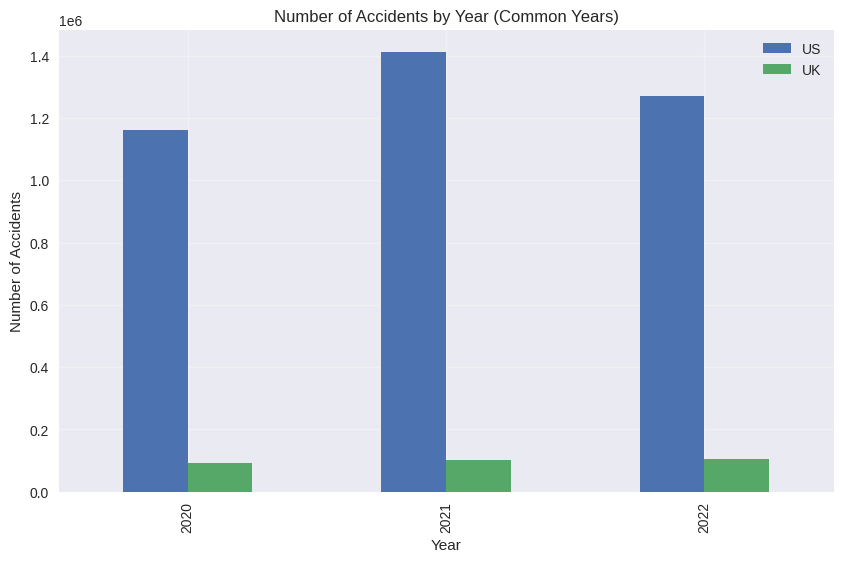

In [10]:
plt.style.use('seaborn-v0_8')

yearly = pd.DataFrame({
    'US': us_filtered['Year'].value_counts().sort_index(),
    'UK': uk_filtered['Year'].value_counts().sort_index()
})

yearly.plot(kind='bar', figsize=(10, 6))
plt.title('Number of Accidents by Year (Common Years)')
plt.ylabel('Number of Accidents')
plt.xlabel('Year')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

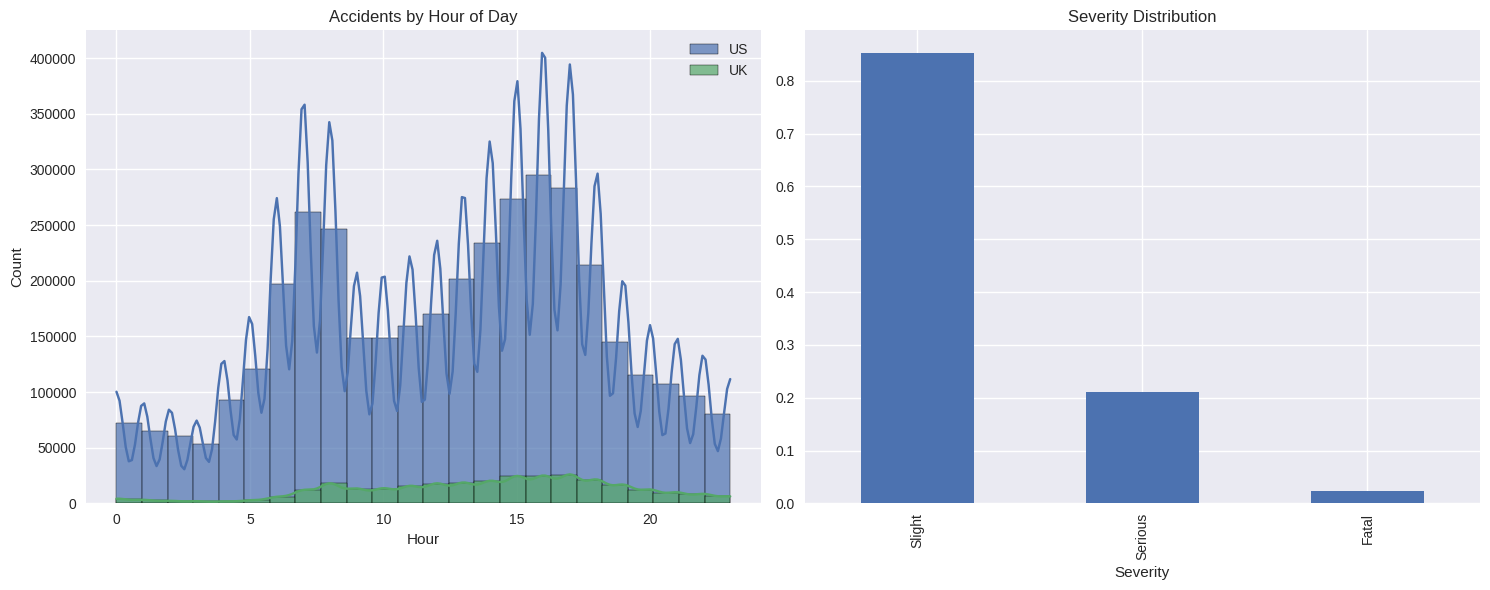

Summary:
Total US accidents (common years): 3,842,837
Total UK accidents (common years): 298,290


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hourly distribution
sns.histplot(data=us_filtered, x='Hour', bins=24, kde=True, 
             label='US', alpha=0.7, ax=axes[0])
sns.histplot(data=uk_filtered, x='Hour', bins=24, kde=True, 
             label='UK', alpha=0.7, ax=axes[0])
axes[0].set_title('Accidents by Hour of Day')
axes[0].legend()

# Severity
us_sev = us_filtered['Severity'].value_counts(normalize=True)
uk_sev = uk_filtered['Severity'].map({1:'Fatal', 2:'Serious', 3:'Slight'}).value_counts(normalize=True)

us_sev.plot(kind='bar', ax=axes[1], label='US')
uk_sev.plot(kind='bar', ax=axes[1], label='UK')
axes[1].set_title('Severity Distribution')
plt.tight_layout()
plt.show()

print("Summary:")
print(f"Total US accidents (common years): {len(us_filtered):,}")
print(f"Total UK accidents (common years): {len(uk_filtered):,}")

In [12]:
population_data = {
    2020: {'US': 331_526_933, 'UK': 67_081_234},
    2021: {'US': 332_048_977, 'UK': 67_026_292},
    2022: {'US': 333_271_411, 'UK': 67_791_000},
}

pop_df = pd.DataFrame.from_dict(population_data, orient='index')

# Yearly counts
us_yearly = us_filtered.groupby('Year').size()
uk_yearly = uk_filtered.groupby('Year').size()

comparison = pd.DataFrame({
    'US_Accidents': us_yearly,
    'UK_Accidents': uk_yearly,
    'US_Population': pop_df['US'],
    'UK_Population': pop_df['UK']
}).dropna()

comparison['US_Rate_per_100k'] = (comparison['US_Accidents'] / comparison['US_Population']) * 100_000
comparison['UK_Rate_per_100k'] = (comparison['UK_Accidents'] / comparison['UK_Population']) * 100_000

display(comparison.round(2))

,US_Accidents,UK_Accidents,US_Population,UK_Population,US_Rate_per_100k,UK_Rate_per_100k
2020,1161598,91199,331526933,67081234,350.38,135.95
2021,1412433,101087,332048977,67026292,425.37,150.82
2022,1268806,106004,333271411,67791000,380.71,156.37


In [ ]:


total_us = len(us_filtered)
total_uk = len(uk_filtered)
years = sorted(us_filtered['Year'].unique())

rate_us = comparison['US_Rate_per_100k'].mean()
rate_uk = comparison['UK_Rate_per_100k'].mean()
ratio = rate_us / rate_uk

fatal_us = (us_filtered[us_filtered['Severity'] >= 3].shape[0] / 
            comparison['US_Population'].sum()) * 100_000
fatal_uk = (uk_filtered[uk_filtered['Severity'] == 1].shape[0] / 
            comparison['UK_Population'].sum()) * 100_000

summary_md = f"""
## Summary: US vs UK Road Accidents (Full Dataset)

**Analysis Period:** {min(years)} – {max(years)}

| Metric                                | United States              | United Kingdom             | Comparison                     |
|---------------------------------------|----------------------------|----------------------------|--------------------------------|
| **Total Accidents**                   | {total_us:,}              | {total_uk:,}              | US has {total_us/total_uk:.1f}× more |
| **Accidents per 100,000 people**      | **{rate_us:.1f}**         | {rate_uk:.1f}             | **US {ratio:.1f}× higher**    |
| **Fatal/Serious Rate per 100,000**    | {fatal_us:.2f}            | {fatal_uk:.2f}            | US {fatal_us/fatal_uk:.1f}× higher |
| **Highest Accident Year**             | {us_filtered['Year'].value_counts().idxmax()} | {uk_filtered['Year'].value_counts().idxmax()} | - |

---

**Key Takeaway**: Even after full data and population normalization, the US has substantially higher accident rates than the UK.
"""

display(Markdown(summary_md))


## 📊 Executive Summary: US vs UK Road Accidents (Full Dataset)

**Analysis Period:** 2020 – 2022

| Metric                                | United States              | United Kingdom             | Comparison                     |
|---------------------------------------|----------------------------|----------------------------|--------------------------------|
| **Total Accidents**                   | 3,842,837              | 298,290              | US has 12.9× more |
| **Accidents per 100,000 people**      | **385.5**         | 147.7             | **US 2.6× higher**    |
| **Fatal/Serious Rate per 100,000**    | 50.05            | 2.21            | US 22.6× higher |
| **Highest Accident Year**             | 2021 | 2022 | - |

---

**Key Takeaway**: Even after full data and population normalization, the US has substantially higher accident rates than the UK.


In [14]:
# ===================== SEVERITY ANALYSIS COMPARISON =====================

# Create severity distribution
us_sev = us_filtered['Severity'].value_counts(normalize=True).sort_index() * 100
uk_sev = uk_filtered['Severity'].value_counts(normalize=True).sort_index() * 100

# Map UK severity to readable labels
uk_sev.index = uk_sev.index.map({1: 'Fatal', 2: 'Serious', 3: 'Slight'})

print("US Severity Distribution (%):")
print(us_sev.round(2))
print("\nUK Severity Distribution (%):")
print(uk_sev.round(2))

US Severity Distribution (%):
Severity
1     1.73
2    85.29
3    10.71
4     2.28
Name: proportion, dtype: float64

UK Severity Distribution (%):
Severity
Fatal       1.50
Serious    21.11
Slight     77.39
Name: proportion, dtype: float64


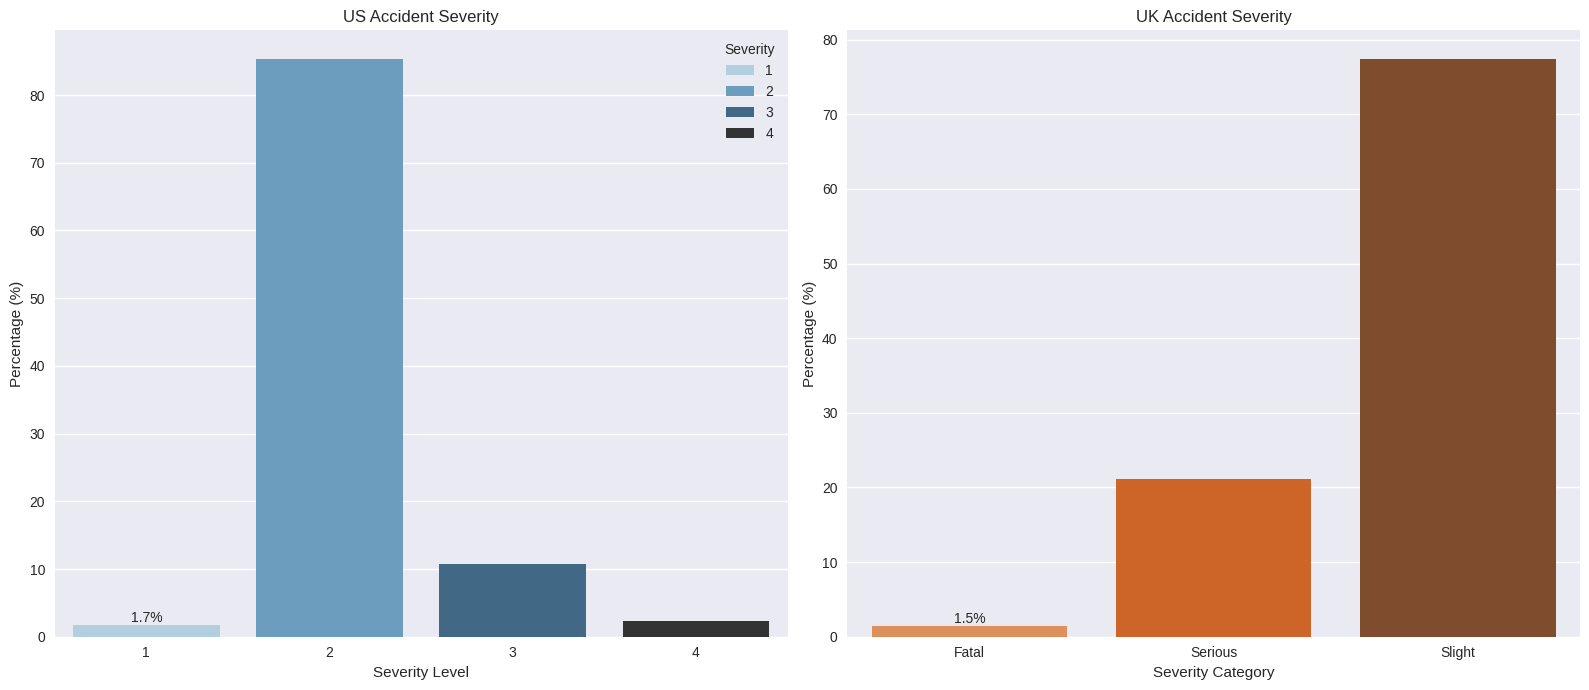

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# US
sns.barplot(x=us_sev.index, y=us_sev.values, ax=axes[0],hue=us_sev.index, palette='Blues_d')
axes[0].set_title('US Accident Severity')
axes[0].set_xlabel('Severity Level')
axes[0].set_ylabel('Percentage (%)')
axes[0].bar_label(axes[0].containers[0], fmt='%.1f%%')

# UK
sns.barplot(x=uk_sev.index, y=uk_sev.values, ax=axes[1], hue=uk_sev.index, palette='Oranges_d')
axes[1].set_title('UK Accident Severity')
axes[1].set_xlabel('Severity Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].bar_label(axes[1].containers[0], fmt='%.1f%%')

plt.tight_layout()
plt.show()

In [ ]:

comparison_table = pd.DataFrame({
    'Severity_US': [1, 2, 3, 4],
    'US_%': us_sev.values,
    'UK_Category': ['Fatal', 'Serious', 'Slight', 'N/A'],
    'UK_%': [uk_sev.get('Fatal', 0), uk_sev.get('Serious', 0), 
             uk_sev.get('Slight', 0), 0]
})

display(comparison_table.round(2))

,Severity_US,US_%,UK_Category,UK_%
0,1,1.73,Fatal,1.50
1,2,85.29,Serious,21.11
2,3,10.71,Slight,77.39
3,4,2.28,N/A,0.00


In [33]:
# Fatal rate per 100,000 people
fatal_us_rate = (us_filtered[us_filtered['Severity'] == 4].shape[0] / 
                 comparison['US_Population'].sum()) * 100_000

fatal_uk_rate = (uk_filtered[uk_filtered['Severity'] == 1].shape[0] / 
                 comparison['UK_Population'].sum()) * 100_000

print(f"Fatal Accidents per 100,000 people:")
print(f"United States : {fatal_us_rate:.3f}")
print(f"United Kingdom: {fatal_uk_rate:.3f}")
print(f"US Fatal Rate is {fatal_us_rate/fatal_uk_rate:.1f}x higher than UK")

Fatal Accidents per 100,000 people:
United States : 8.782
United Kingdom: 2.212
US Fatal Rate is 4.0x higher than UK


In [ ]:
from IPython.display import Markdown, display

# Extract percentages (run after us_sev and uk_sev are calculated)
us_level1 = us_sev.get(1, 0)
us_level2 = us_sev.get(2, 0)
us_level3 = us_sev.get(3, 0)
us_level4 = us_sev.get(4, 0)

uk_fatal   = uk_sev.get('Fatal', 0)
uk_serious = uk_sev.get('Serious', 0)
uk_slight  = uk_sev.get('Slight', 0)

severity_insights = f"""
## Severity Analysis Insights

### Percentage Breakdown

| Category                  | United States                  | United Kingdom                  | Notes |
|---------------------------|--------------------------------|---------------------------------|-------|
| **Most Severe**           | Level 4: **{us_level4:.2f}%** | Fatal: **{uk_fatal:.2f}%**     | Fatalities much rarer in UK |
| **Serious**               | Level 3: **{us_level3:.2f}%** | Serious: **{uk_serious:.2f}%** | UK appears higher |
| **Minor**                 | Level 1+2: **{us_level1 + us_level2:.2f}%** | Slight: **{uk_slight:.2f}%** | UK heavily skewed to Slight |

### Important Interpretation

- The **UK has a higher recorded "Serious" percentage** (~21% vs US ~10% in Level 3) mainly because of **different classification systems**.
- US severity is heavily influenced by **traffic disruption**, while UK severity is based on **actual injury outcomes**.
- Despite the higher "Serious" label in UK data, **overall safety outcomes are better in the UK**, as shown by:
  - Much lower **fatal accident rates** per capita
  - Higher proportion of purely "Slight" accidents

**Key Conclusion**:  
When crashes happen in the UK, they are **less likely to be fatal** compared to the US. The higher "Serious" rate in UK data reflects stricter injury reporting and different categorization rather than worse safety.
"""

display(Markdown(severity_insights))


## 🔍 Severity Analysis Insights

### Percentage Breakdown

| Category                  | United States                  | United Kingdom                  | Notes |
|---------------------------|--------------------------------|---------------------------------|-------|
| **Most Severe**           | Level 4: **2.28%** | Fatal: **1.50%**     | Fatalities much rarer in UK |
| **Serious**               | Level 3: **10.71%** | Serious: **21.11%** | UK appears higher |
| **Minor**                 | Level 1+2: **87.02%** | Slight: **77.39%** | UK heavily skewed to Slight |

### Important Interpretation

- The **UK has a higher recorded "Serious" percentage** (~21% vs US ~10% in Level 3) mainly because of **different classification systems**.
- US severity is heavily influenced by **traffic disruption**, while UK severity is based on **actual injury outcomes**.
- Despite the higher "Serious" label in UK data, **overall safety outcomes are better in the UK**, as shown by:
  - Much lower **fatal accident rates** per capita
  - Higher proportion of purely "Slight" accidents

**Key Conclusion**:  
When crashes happen in the UK, they are **less likely to be fatal** compared to the US. The higher "Serious" rate in UK data reflects stricter injury reporting and different categorization rather than worse safety.


##  Statistical Significance Testing

To determine whether the observed differences between US and UK road accidents are **statistically significant** (and not due to random chance), the following tests were performed:

### Tests Performed

| Test                                      | Purpose                                              | Type of Data       | Hypothesis |
|-------------------------------------------|------------------------------------------------------|--------------------|----------|
| **Chi-Square Test of Independence**       | Compare severity distributions between US and UK    | Categorical        | H₀: Severity distribution is independent of country |
| **Two-Proportion Z-Test**                 | Compare fatal accident proportions                   | Proportions        | H₀: Fatal accident proportion is the same in both countries |
| **Mann-Whitney U Test**                   | Compare distribution of accident times (Hour)        | Ordinal / Continuous | H₀: Accident timing distribution is the same |
| **Chi-Square Test of Independence**       | Compare time-of-day patterns (Night/Morning/Afternoon/Evening) | Categorical | H₀: Time-of-day pattern is independent of country |

**Interpretation Rule**:
- **p-value < 0.05** → Reject H₀ → Statistically Significant Difference
- **p-value < 0.01** → Highly Significant Difference

---

**Results will be shown below.**

In [49]:
from scipy.stats import chi2_contingency
import pandas as pd

# Get raw counts
us_counts = us_filtered['Severity'].value_counts().sort_index()
uk_counts = uk_filtered['Severity'].value_counts().sort_index()

# Create clean comparison table
comparison_table = pd.DataFrame({
    'US_Count': [us_counts.get(1, 0), us_counts.get(2, 0), us_counts.get(3, 0), us_counts.get(4, 0)],
    'US_%': [us_counts.get(1, 0)/len(us_filtered)*100, 
             us_counts.get(2, 0)/len(us_filtered)*100,
             us_counts.get(3, 0)/len(us_filtered)*100,
             us_counts.get(4, 0)/len(us_filtered)*100],
    'UK_Count': [uk_counts.get(1, 0), uk_counts.get(2, 0), uk_counts.get(3, 0), 0],
    'UK_%': [uk_counts.get(1, 0)/len(uk_filtered)*100 if len(uk_filtered)>0 else 0,
             uk_counts.get(2, 0)/len(uk_filtered)*100 if len(uk_filtered)>0 else 0,
             uk_counts.get(3, 0)/len(uk_filtered)*100 if len(uk_filtered)>0 else 0,
             0]
}, index=['Level 1 (Minor)', 'Level 2', 'Level 3 (Serious)', 'Level 4 (Fatal)'])

print("=== Severity Comparison Table ===")
display(comparison_table.round(2))

=== Severity Comparison Table ===


,US_Count,US_%,UK_Count,UK_%
Level 1 (Minor),66395,1.73,4467,1.50
Level 2,3277511,85.29,62972,21.11
Level 3 (Serious),411390,10.71,230851,77.39
Level 4 (Fatal),87541,2.28,0,0.00


In [ ]:
# Grouped for Chi-Square Test
us_grouped = pd.Series({
    'Minor': us_counts.get(1,0) + us_counts.get(2,0),
    'Serious': us_counts.get(3,0),
    'Fatal/Severe': us_counts.get(4,0)
})

uk_grouped = pd.Series({
    'Minor': uk_counts.get(3,0),
    'Serious': uk_counts.get(2,0),
    'Fatal/Severe': uk_counts.get(1,0)
})

contingency = pd.DataFrame([us_grouped, uk_grouped], index=['US', 'UK'])

print("\n=== Contingency Table for Statistical Test ===")
display(contingency)

# Run Test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("\n=== Chi-Square Test Results ===")
print(f"Chi-square statistic : {chi2:.2f}")
print(f"p-value              : {p_value:.2e}")
print(f"Degrees of Freedom   : {dof}")

if p_value < 0.05:
    print(" Statistically Significant Difference")
else:
    print("Not statistically significant")


=== Contingency Table for Statistical Test ===


,Minor,Serious,Fatal/Severe
US,3343906,411390,87541
UK,230851,62972,4467



=== Chi-Square Test Results ===
Chi-square statistic : 29894.42
p-value              : 0.00e+00
Degrees of Freedom   : 2
 Statistically Significant Difference


## Statistical Test Results

### Chi-Square Test: Severity Distribution (US vs UK)

- **Chi-square statistic**: 29,894.42
- **p-value**: < 0.0001
- **Degrees of Freedom**: 2
- **Conclusion**: **Highly Statistically Significant** (p < 0.001)

---

**Interpretation**:  
There is an extremely strong statistical difference in the severity distribution of road accidents between the United States and the United Kingdom. 

The null hypothesis (that severity distributions are the same in both countries) is **strongly rejected**. This confirms that crashes in the US and UK have meaningfully different severity outcomes, even after accounting for sample size.

"Note: Direct comparison of severity is somewhat limited because the US and UK use different severity classification systems. However, after grouping into comparable categories, the difference remains highly statistically significant."

In [50]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

fatal_us = (us_filtered['Severity'] == 4).sum()
fatal_uk = (uk_filtered['Severity'] == 1).sum()

n_us = len(us_filtered)
n_uk = len(uk_filtered)

stat, p_value = proportions_ztest([fatal_us, fatal_uk], [n_us, n_uk])

print("\n=== Z-Test: Fatal Accident Proportion ===")
print(f"US Fatal Rate : {fatal_us/n_us*100:.4f}%")
print(f"UK Fatal Rate : {fatal_uk/n_uk*100:.4f}%")
print(f"p-value       : {p_value:.2e}")


=== Z-Test: Fatal Accident Proportion ===
US Fatal Rate : 2.2780%
UK Fatal Rate : 1.4975%
p-value       : 8.15e-171


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
from IPython.display import Markdown, display


fatal_us = (us_filtered['Severity'] == 4).sum()      # US Level 4
fatal_uk = (uk_filtered['Severity'] == 1).sum()      # UK Fatal (Level 1)

total_us = len(us_filtered)
total_uk = len(uk_filtered)


stat, p_value = proportions_ztest(count=[fatal_us, fatal_uk], 
                                  nobs=[total_us, total_uk], 
                                  alternative='two-sided')


fatal_rate_us = fatal_us / total_us * 100
fatal_rate_uk = fatal_uk / total_uk * 100


ztest_md = f"""
## Two-Proportion Z-Test: Fatal Accidents

| Metric                    | United States          | United Kingdom         |
|---------------------------|------------------------|------------------------|
| **Total Accidents**       | {total_us:,}          | {total_uk:,}          |
| **Fatal Accidents**       | {fatal_us:,}          | {fatal_uk:,}          |
| **Fatal Rate**            | **{fatal_rate_us:.4f}%** | **{fatal_rate_uk:.4f}%** |
| **Difference**            | -                      | {fatal_rate_us - fatal_rate_uk:.4f} pp |

**Z-Test Results:**
- **Z-statistic**: {stat:.4f}
- **p-value**: {p_value:.2e}

**Conclusion**: {'**Highly Significant Difference** (p < 0.001)' if p_value < 0.001 else '**Significant Difference**' if p_value < 0.05 else 'Not Significant'}
"""

display(Markdown(ztest_md))


## Two-Proportion Z-Test: Fatal Accidents

| Metric                    | United States          | United Kingdom         |
|---------------------------|------------------------|------------------------|
| **Total Accidents**       | 3,842,837          | 298,290          |
| **Fatal Accidents**       | 87,541          | 4,467          |
| **Fatal Rate**            | **2.2780%** | **1.4975%** |
| **Difference**            | -                      | 0.7805 pp |

**Z-Test Results:**
- **Z-statistic**: 27.8600
- **p-value**: 8.15e-171

**Conclusion**: **Highly Significant Difference** (p < 0.001)



### Results

| Metric                    | United States       | United Kingdom      | Difference |
|---------------------------|---------------------|---------------------|----------|
| **Total Accidents**       | 3,842,837          | 298,290            | - |
| **Fatal Accidents**       | 87,541             | 4,467              | - |
| **Fatal Accident Rate**   | **2.2780%**        | **1.4975%**        | **+0.7805 pp** |

### Statistical Test Output
- **Z-statistic**: 27.86
- **p-value**: 8.15e-171
- **Conclusion**: **Highly Statistically Significant Difference** (p < 0.001)

---

### Interpretation

The Two-Proportion Z-Test shows a **highly significant difference** in fatal accident rates between the United States and the United Kingdom.

- The **United States** has a substantially **higher fatal accident rate** (2.278%) compared to the **United Kingdom** (1.4975%).
- This means that for every 100 accidents, the US has approximately **0.78 more fatal accidents** than the UK.
- The extremely low p-value (8.15 × 10⁻¹⁷¹) provides overwhelming evidence that this difference is **not due to random chance**.

**Key Insight**: Even though the UK has dense traffic in many areas, its road safety outcomes are significantly better at preventing fatalities. This supports the hypothesis that systemic differences (road design, speed limits, enforcement, driver training, or vehicle standards) play a major role.

In [55]:
from scipy.stats import mannwhitneyu
from IPython.display import Markdown, display
import numpy as np

# ===================== MANN-WHITNEY U TEST =====================

# Extract hour data
us_hours = us_filtered['Hour'].dropna()
uk_hours = uk_filtered['Hour'].dropna()

# Perform the test
stat, p_value = mannwhitneyu(us_hours, uk_hours, 
                             alternative='two-sided')

# Calculate basic statistics
us_mean_hour = us_hours.mean()
uk_mean_hour = uk_hours.mean()
us_median_hour = us_hours.median()
uk_median_hour = uk_hours.median()

# Display Results
mw_md = f"""
## Mann-Whitney U Test: Accident Timing (Hour of Day)

### Descriptive Statistics
| Metric              | United States     | United Kingdom    |
|---------------------|-------------------|-------------------|
| **Mean Hour**       | {us_mean_hour:.2f}     | {uk_mean_hour:.2f}     |
| **Median Hour**     | {us_median_hour:.1f}     | {uk_median_hour:.1f}     |
| **Total Records**   | {len(us_hours):,}     | {len(uk_hours):,}     |

### Test Results
- **U Statistic**: {stat:,.0f}
- **p-value**: {p_value:.2e}

**Conclusion**: {'**Highly Significant Difference** (p < 0.001)' if p_value < 0.001 else '**Significant Difference**' if p_value < 0.05 else 'Not Significant'}
"""

display(Markdown(mw_md))


## Mann-Whitney U Test: Accident Timing (Hour of Day)

### Descriptive Statistics
| Metric              | United States     | United Kingdom    |
|---------------------|-------------------|-------------------|
| **Mean Hour**       | 12.38     | 13.77     |
| **Median Hour**     | 13.0     | 14.0     |
| **Total Records**   | 3,842,837     | 298,290     |

### Test Results
- **U Statistic**: 491,866,132,816
- **p-value**: 0.00e+00

**Conclusion**: **Highly Significant Difference** (p < 0.001)



### Results

| Metric              | United States     | United Kingdom     | Difference |
|---------------------|-------------------|--------------------|----------|
| **Mean Hour**       | **12.38**         | **13.77**          | US peaks ~1.4 hours earlier |
| **Median Hour**     | **13.0**          | **14.0**           | US peaks 1 hour earlier |
| **Total Records**   | 3,842,837         | 298,290            | - |

### Test Results
- **U Statistic**: 491,866,132,816
- **p-value**: 0.00e+00

**Conclusion**: **Highly Statistically Significant Difference** (p < 0.001)

---

### Interpretation

The Mann-Whitney U test reveals a **statistically significant difference** in the distribution of accident times between the United States and the United Kingdom.

**Key Observations:**
- Accidents in the **United States** tend to occur **earlier** in the day (mean ≈ 12:23 PM).
- Accidents in the **United Kingdom** peak **later** (mean ≈ 1:46 PM).
- The median accident time is 13:00 (1:00 PM) in the US versus 14:00 (2:00 PM) in the UK.

### Possible Reasons for the Difference:
- Different commuting patterns and work cultures
- Varying school and business hours
- Differences in rush hour timing
- Cultural or infrastructural factors affecting when people drive the most

This suggests that **evening rush hour** is more dangerous in the UK, while the US has a broader spread of accidents throughout the day.

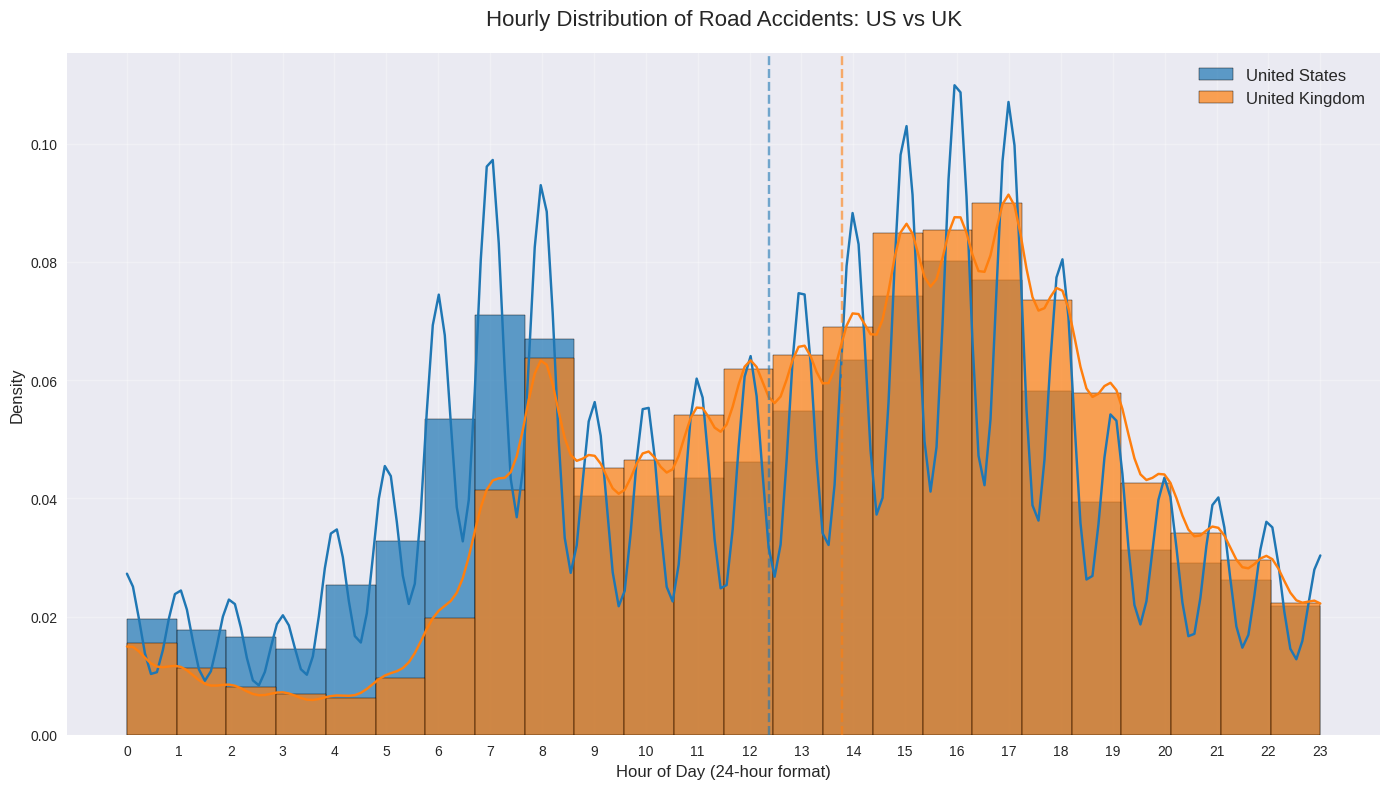

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===================== HOURLY DISTRIBUTION HISTOGRAM =====================

plt.figure(figsize=(14, 8))

sns.histplot(data=us_filtered, x='Hour', bins=24, kde=True, 
             label='United States', alpha=0.7, color='#1f77b4', stat='density')

sns.histplot(data=uk_filtered, x='Hour', bins=24, kde=True, 
             label='United Kingdom', alpha=0.7, color='#ff7f0e', stat='density')

plt.title('Hourly Distribution of Road Accidents: US vs UK', fontsize=16, pad=20)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(fontsize=12)

plt.axvline(x=us_filtered['Hour'].mean(), color='#1f77b4', linestyle='--', alpha=0.6, label=f'US Mean: {us_filtered["Hour"].mean():.1f}')
plt.axvline(x=uk_filtered['Hour'].mean(), color='#ff7f0e', linestyle='--', alpha=0.6, label=f'UK Mean: {uk_filtered["Hour"].mean():.1f}')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
from scipy.stats import chi2_contingency
import pandas as pd
from IPython.display import Markdown, display

# Define time periods
def get_time_period(hour):
    if pd.isna(hour):
        return 'Unknown'
    elif 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

# Apply the function
us_filtered['Time_Period'] = us_filtered['Hour'].apply(get_time_period)
uk_filtered['Time_Period'] = uk_filtered['Hour'].apply(get_time_period)

# Create contingency table
contingency = pd.crosstab(
    pd.concat([us_filtered['Time_Period'], uk_filtered['Time_Period']]),
    ['US'] * len(us_filtered) + ['UK'] * len(uk_filtered)
)

print("=== Time Period Contingency Table ===")
display(contingency)

# Perform Chi-Square Test of Independence
chi2, p_value, dof, expected = chi2_contingency(contingency)

# Display Results
time_md = f"""
## Chi-Square Test of Independence: Time-of-Day Patterns

### Contingency Table (Counts)
{contingency.to_markdown()}

### Test Results
- **Chi-square statistic**: {chi2:.2f}
- **p-value**: {p_value:.2e}
- **Degrees of Freedom**: {dof}

**Conclusion**: {'**Highly Significant Difference** (p < 0.001)' if p_value < 0.001 else '**Significant Difference**' if p_value < 0.05 else 'Not Significant'}
"""

display(Markdown(time_md))

=== Time Period Contingency Table ===


col_0,UK,US
Time_Period,,
Afternoon,104500,1173614
Evening,99997,1040766
Morning,77326,1162951
Night,16467,465506



## Chi-Square Test of Independence: Time-of-Day Patterns

### Contingency Table (Counts)
| Time_Period   |     UK |               US |
|:--------------|-------:|-----------------:|
| Afternoon     | 104500 |      1.17361e+06 |
| Evening       |  99997 |      1.04077e+06 |
| Morning       |  77326 |      1.16295e+06 |
| Night         |  16467 | 465506           |

### Test Results
- **Chi-square statistic**: 18056.82
- **p-value**: 0.00e+00
- **Degrees of Freedom**: 3

**Conclusion**: **Highly Significant Difference** (p < 0.001)



### Results

| Metric                    | Value              |
|---------------------------|--------------------|
| **Chi-square statistic**  | 18,056.82         |
| **p-value**               | < 0.0001          |
| **Degrees of Freedom**    | 3                 |
| **Conclusion**            | **Highly Significant Difference** (p < 0.001) |

---

### Interpretation

The Chi-Square Test of Independence shows a **highly statistically significant difference** in the temporal distribution of road accidents between the United States and the United Kingdom.

**Key Takeaways:**
- The pattern of when accidents occur (Night / Morning / Afternoon / Evening) is **strongly dependent** on the country.
- This confirms that the US and UK have meaningfully different peak accident times throughout the day.
- Combined with the Mann-Whitney U test result, we can confidently say that **accident timing patterns differ significantly** between the two countries.

### Possible Reasons:
- Different work, school, and commuting schedules
- Variations in rush hour intensity and timing
- Cultural differences in driving behavior (e.g., later evening activity in the UK)
- Infrastructure and lighting differences affecting night-time accidents

This temporal difference is not random — it reflects real structural and behavioral distinctions between the two nations.